# Alignment-free phylogenetic analysis of betacoronaviruses

In [1]:
from kaospy import FCGRCollection
from Bio import SeqIO
import numpy as np
from Bio.Phylo.TreeConstruction import DistanceMatrix
from Bio.Phylo.TreeConstruction import DistanceTreeConstructor
from pathlib import Path
import pandas as pd
from Bio import Phylo
import matplotlib.pyplot as plt

### Reading the files: 
For an easier overveiw, short names are lsietet in a file called names.csv

In [2]:
names_df = pd.read_csv(
    "data/coronavirus/names.csv",
    header=None
)

name_mapping = dict(
    zip(
        names_df[0],
        names_df[1]
    )
)

In [3]:
folder = Path("data/coronavirus")
files = sorted(folder.glob("*.fasta"))


<br>
All non A, G, C, T characters were removed:

In [4]:
sequences = {}

for file in sorted(folder.glob("*.fasta")):
    record = SeqIO.read(file, "fasta")

    seq = str(record.seq).upper()
    seq = "".join(base for base in seq if base in "AGCT")

    sequences[record.description] = seq
    

<br>

## Encoding to FCGR

In [5]:
coronavirus_collection = FCGRCollection(
    sequences,
    symbols="DNA",
    resolution=16
)

fcgrs = coronavirus_collection.fcgrs


<br>

### Calculationg the distance matrix with euclidean metrik

In [6]:

names = list(fcgrs.keys())

distance_matrix = np.array([
    [
        fcgrs[name_i].distance(
            fcgrs[name_j],
            method="euclidean"
        )
        for name_j in names
    ]
    for name_i in names
])



<br>

### Formatting for biopython

In [7]:
names = list(coronavirus_collection.fcgr_names())

dm = DistanceMatrix(
    names,
    [
        list(row[:i+1])
        for i, row in enumerate(distance_matrix)
    ]
)


<br> 

### Tree construction

In [8]:

constructor = DistanceTreeConstructor()

nj_tree = constructor.nj(dm)
upgma_tree = constructor.upgma(dm)

<br>

## Visualiszation of both Trees

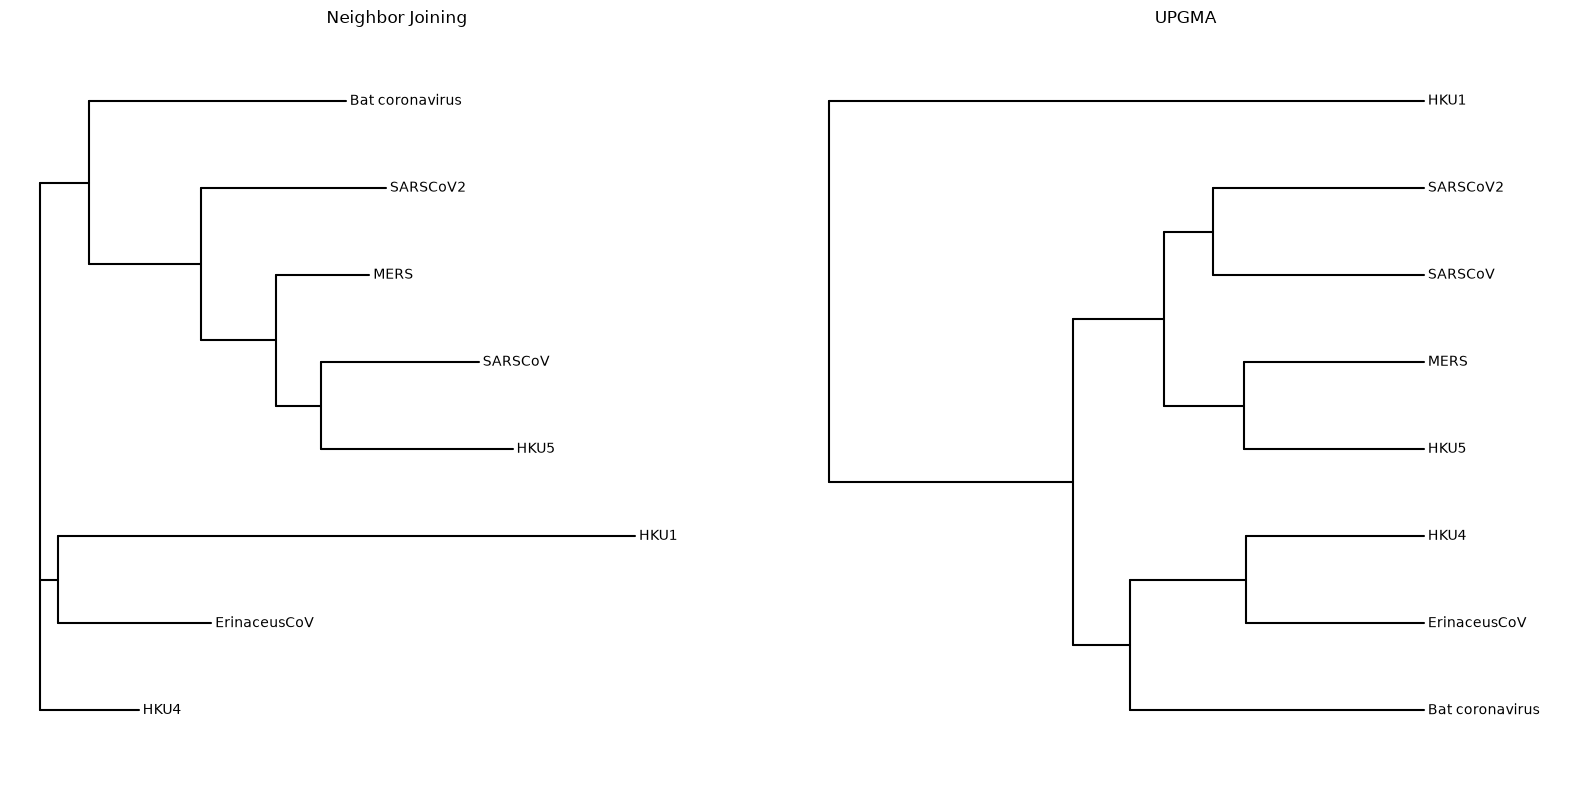

In [9]:


for tree in [nj_tree, upgma_tree]:
    for clade in tree.get_terminals():
        if clade.name in name_mapping:
            clade.name = name_mapping[clade.name]

    for clade in tree.get_nonterminals():
        clade.name = None


fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 8)
)

Phylo.draw(
    nj_tree,
    axes=axes[0],
    do_show=False
)

for text in axes[0].texts:
    text.set_fontsize(22)

axes[0].set_title("Neighbor Joining", fontsize=18)
axes[0].set_axis_off()


Phylo.draw(
    upgma_tree,
    axes=axes[1],
    do_show=False
)

for text in axes[1].texts:
    text.set_fontsize(22)

axes[1].set_title("UPGMA", fontsize=18)
axes[1].set_axis_off()


plt.tight_layout()
plt.show()